In [39]:
import pandas as pd

df_control = pd.read_csv("df_control_updated.csv")
df_test = pd.read_csv("df_test_updated.csv")

In [41]:
df_test.head(5)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation,visitor_id,visit_id,process_step,date_time
0,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56
1,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03
2,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35
3,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14
4,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34


In [80]:
# converting the "date_time" into a datetime type
df_control["date_time"] = pd.to_datetime(df_control["date_time"])
df_test["date_time"] = pd.to_datetime(df_test["date_time"])

In [50]:
df_test['process_step'].unique()

['confirm', 'start', 'step_1', 'step_2', 'step_3', NaN]
Categories (5, str): ['start' < 'step_1' < 'step_2' < 'step_3' < 'confirm']

In [53]:
# Droping missing values
df_test = df_test.dropna(subset=["process_step"])

In [56]:
df_test['process_step'].unique()

['confirm', 'start', 'step_1', 'step_2', 'step_3']
Categories (5, str): ['start' < 'step_1' < 'step_2' < 'step_3' < 'confirm']

In [81]:
# Let's clean each group by creating a reusable function
def prepare_group(df):
    df = df.copy()
    
    # Sort by user and time
    df = df.sort_values(["visit_id", "date_time"])
    
    # Keep only last start and confirm
    steps_to_dedup = ["start", "confirm"]
    
    df_special = df[df["process_step"].isin(steps_to_dedup)]
    df_special_last = df_special.drop_duplicates(
        subset=["visit_id", "process_step"],
        keep="last"
    )

    # Keep all other steps untouched
    df_other = df[~df["process_step"].isin(steps_to_dedup)]

    # Combine everything back
    df_clean = pd.concat([df_special_last, df_other]) \
                 .sort_values(["visit_id", "date_time"])
    
    # Compute time between steps
    df_clean["time_spent"] = df_clean.groupby("visit_id")["date_time"].diff().dt.total_seconds()
    
    # Remove start (no time)
    df_clean = df_clean[df_clean["process_step"] != "start"]
    
    return df_clean

In [82]:
df_test_clean = prepare_group(df_test)
df_control_clean = prepare_group(df_control)

**Let's check if the completion times of all the steps of the process are the same for test group:**


In [83]:
# For test group
from scipy.stats import f_oneway

# Group and aggregate data
df_test_agg = df_test_clean.groupby(
    ["visit_id", "process_step"]
)["time_spent"].mean().unstack() # converts from long to wide format

# Drop missing users
df_test_agg = df_test_agg.dropna()

# Ensure numeric data
df_test_agg = df_test_agg.apply(pd.to_numeric, errors="coerce")

# ANOVA
f_stat, p_value = f_oneway(
    df_test_agg["step_1"],
    df_test_agg["step_2"],
    df_test_agg["step_3"],
    df_test_agg["confirm"]
)

print("Test group p-value:", p_value)

Test group p-value: 0.0


In [84]:
print(df_test_agg.mean())

process_step
step_1      43.526135
step_2      43.082908
step_3      92.688795
confirm    143.570256
dtype: float64


In [85]:
print(df_test_agg.head())
print(df_test_agg.dtypes)

process_step                  step_1  step_2  step_3  confirm
visit_id                                                     
100019538_17884295066_43909      5.0     4.0   113.0     57.0
100022086_87870757897_149620    22.0    45.0    53.0     60.0
100173292_91322748906_143563    11.0     8.0    48.0     28.0
100217156_67053490690_383412   755.0    11.0    99.0    152.0
100258507_71262593004_214494     3.0   208.0    29.0    111.0
process_step
step_1     float64
step_2     float64
step_3     float64
confirm    float64
dtype: object


<Axes: xlabel='process_step'>

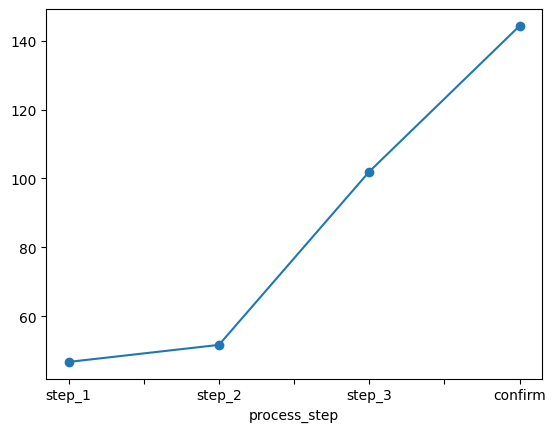

In [101]:
df_test_means = df_test_clean.groupby("process_step")["time_spent"].mean()
df_test_means.plot(kind="line", marker='o')

**Let's check if the completion times of all the steps of the process are the same for control group:**

In [112]:
# For control group
from scipy.stats import f_oneway

df_control_agg = df_control_clean.groupby(
    ["visit_id", "process_step"]
)["time_spent"].mean().unstack()

df_control_agg = df_control_agg.apply(pd.to_numeric, errors="coerce")

step_order = ["step_1", "step_2", "step_3", "confirm"]
df_control_agg = df_control_agg[step_order]

df_control_agg = df_control_agg.dropna()

f_stat, p_value = f_oneway(
    df_control_agg["step_1"],
    df_control_agg["step_2"],
    df_control_agg["step_3"],
    df_control_agg["confirm"]
)

print("Control group p-value:", p_value)

Control group p-value: 0.0


In [113]:
print(df_control_agg.mean())

process_step
step_1      41.925571
step_2      35.568044
step_3      92.217540
confirm    137.358074
dtype: float64


<Axes: xlabel='process_step'>

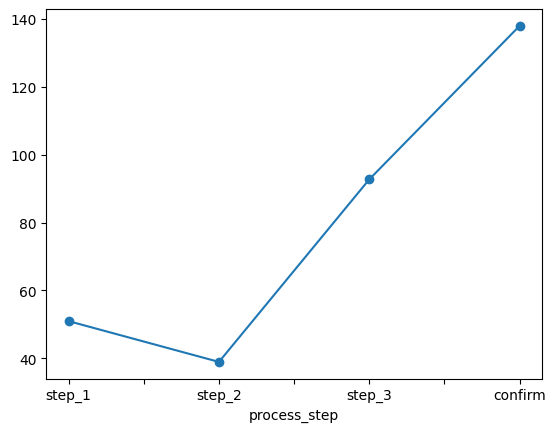

In [115]:
df_control_means = df_control_clean.groupby("process_step")["time_spent"].mean()
df_control_means = df_control_means.reindex(step_order)
df_control_means.plot(kind="line", marker='o')

**Now let's see between groups:**

In [94]:
# Independent two-sample t-test
# Significance level = 5%
from scipy.stats import ttest_ind

# Test - Group by user and step, take the mean and keeps data in long format
df_test_agg = df_test_clean.groupby(
    ["visit_id", "process_step"]      
)["time_spent"].mean().reset_index()  

# Control - Group by user and step, take the mean and keeps data in long format
df_control_agg = df_control_clean.groupby(
    ["visit_id", "process_step"]
)["time_spent"].mean().reset_index()

# Loop through each step
steps = ["step_1", "step_2", "step_3", "confirm"]

# Extract values for each step
for step in steps:
    test_vals = df_test_agg[df_test_agg["process_step"] == step]["time_spent"].dropna()
    control_vals = df_control_agg[df_control_agg["process_step"] == step]["time_spent"].dropna()
    
    print(f"\nStep: {step}")
    print("Test size:", len(test_vals))
    print("Control size:", len(control_vals))
    print("Test std:", test_vals.std())
    print("Control std:", control_vals.std())
    
    if len(test_vals) > 1 and len(control_vals) > 1 and test_vals.std() > 0 and control_vals.std() > 0:
        t_stat, p_value = ttest_ind(test_vals, control_vals, equal_var=False)
        print("p-value:", p_value)
    else:
        print("Cannot compute t-test (data issue)")


Step: step_1
Test size: 24257
Control size: 21843
Test std: 155.88385326069303
Control std: 98.80776045968268
p-value: 0.16734906294380142

Step: step_2
Test size: 23679
Control size: 20050
Test std: 153.2121136250884
Control std: 54.86213724564745
p-value: 1.0549374490302861e-40

Step: step_3
Test size: 21459
Control size: 18150
Test std: 204.22453543293796
Control std: 92.33230714974924
p-value: 3.257030885634936e-05

Step: confirm
Test size: 18245
Control size: 15191
Test std: 359.19473197750534
Control std: 222.71997051514384
p-value: 0.04854150551800966


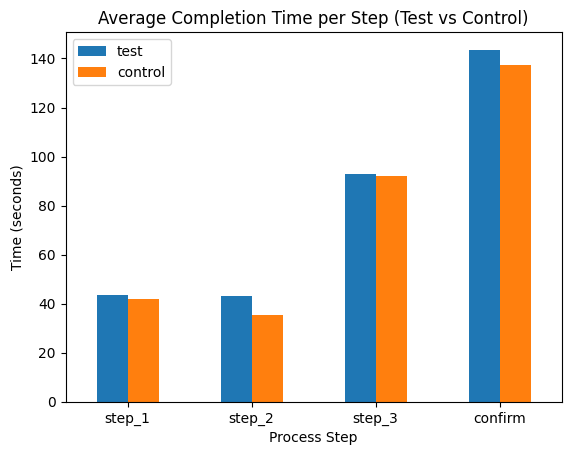

In [96]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.DataFrame({
    "step": ["step_1", "step_2", "step_3", "confirm"],
    "test": [43.53, 43.08, 92.69, 143.57],
    "control": [41.93, 35.57, 92.22, 137.36]
})

data = data.set_index("step")

data.plot(kind="bar")

plt.title("Average Completion Time per Step (Test vs Control)")
plt.xlabel("Process Step")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=0)

plt.show()